In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint
import functools
import itertools
import math

import hydra
import duckdb
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=2, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm
import torch

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [4]:
engine = conf.get_engine()
session = conf.sa.orm.Session(engine)
session.begin()

In [177]:
dataset = [
    'Lorenz96',
    'KuramotoSivashinsky',
    'NavierStokes',
][2]
model = [
    ('EnsembleKalmanFilterPerturbedObservations', 'EnKF-PO'),
    ('EnsembleRandomizedSquareRootFilter', 'EnKF-RSR'),
    ('LocalEnsembleTransformKalmanFilter', 'LETKF'),
][2]
alt_ids = duckdb.sql(f"""
select
    alt_id, '{model[1]}' as label, rng_seed, constant as "Inflation scale", loc_radius_gc as Localizaton from Conf
    join Model on Conf.Model = Model.id
    join ConstantScale on Model.InflationScale = ConstantScale.id
    join {model[0]} on Conf.Model = {model[0]}.id
    join Dataset on Conf.Dataset = Dataset.id
    join {dataset} on Dataset.id = {dataset}.id
    order by rng_seed, constant, loc_radius_gc;
""").pl()
# alt_ids = duckdb.sql(f"""
# select
#     alt_id, 'BPF' as label, rng_seed, constant as "Inflation scale", 'N/A' as Localizaton from Conf
#     join Model on Conf.Model = Model.id
#     join ConstantScale on Model.InflationScale = ConstantScale.id
#     join BootstrapParticleFilter on Conf.Model = BootstrapParticleFilter.id
#     join Dataset on Conf.Dataset = Dataset.id
#     join {dataset} on Dataset.id = {dataset}.id
#     order by rng_seed, constant;
# """).pl()
alt_ids

alt_id,label,rng_seed,Inflation scale,Localizaton
str,str,i64,f64,f64
"""vdvcs5jy""","""LETKF""",2376999025,0.8,1.0
"""pfy092y8""","""LETKF""",2376999025,0.8,2.0
"""cg9ot3ys""","""LETKF""",2376999025,0.8,3.0
"""m2vmj2gl""","""LETKF""",2376999025,0.8,4.0
"""2c35qfer""","""LETKF""",2376999025,0.8,5.0
…,…,…,…,…
"""gzpdp56v""","""LETKF""",2376999025,1.8,4.0
"""otzpd9ko""","""LETKF""",2376999025,1.8,5.0
"""vgzaldr4""","""LETKF""",2376999025,1.8,6.0


In [178]:
cfgs = session.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_(alt_ids.get_column('alt_id'))))
cfgs = {c.alt_id: c for (c,) in cfgs}
rng_seeds = []
cfg_dataset = None
for alt_id in alt_ids.get_column('alt_id'):
    cfg = cfgs[alt_id]
    if cfg_dataset is None:
        cfg_dataset = cfg.dataset
    assert isinstance(cfg.dataset, cfg_dataset.__class__)
    rng_seeds.append(cfg.rng_seed)
rng_seeds = np.array(rng_seeds)
assert (np.diff(rng_seeds) >= 0).all(), 'rng_seeds must be monotonically non-decreasing for dataset caching'

In [179]:
@functools.lru_cache(maxsize=1)
def get_true_state(cfg_dataset, rng_seed):
    lightning.pytorch.seed_everything(rng_seed)
    with lightning.pytorch.utilities.seed.isolate_rng():
        dynamics = datasets.get_dynamics_dataset(cfg_dataset, device=cfg.device)
    true_state = pl.DataFrame(
        torch.cat([dynamics.times, dynamics.true_state[:, 0]], dim=1).cpu().numpy(),
        schema=['times', *(f'true_state_dim_{d}' for d in range(dynamics.true_state[:, 0].shape[1]))],
    )
    del dynamics
    if 'cuda' in cfg.device:
        torch.cuda.empty_cache()
    return true_state

In [180]:
rmses = []
for alt_id in alt_ids.get_column('alt_id'):
    print(alt_id)
    cfg = cfgs[alt_id]

    if not (cfg.run_dir/f'{cfg.prediction_filename}.parquet').exists():
        continue

    true_state = get_true_state(cfg.dataset, cfg.rng_seed)

    alt_id_row = alt_ids.filter(alt_id=alt_id)
    print(alt_id_row)
    
    rmse = (
        pl.scan_parquet(
            cfg.run_dir/f'{cfg.prediction_filename}.parquet',
        )
        # take last X time steps when data assimilation occurred
        .sort('times')
        .gather_every(cfg.dataset.observe_every_n_time_steps, offset=1)  # offset to exclude initial condition
        # .head(1)
        .tail(50)
        
        .join(true_state.lazy(), on='times')
        .select(
            pl.lit(alt_id).alias('alt_id'),
            pl.lit(alt_id_row.get_column('label').item()).alias('label'),
            pl.lit(cfg.rng_seed, dtype=pl.datatypes.Int64).alias('rng_seed'),
            pl.col('times'),
            pl.lit(cfg.model.inflation_scale.constant).alias('Inflation scale'),
            pl.lit(getattr(cfg.model, 'loc_radius_gc', 'N/A')).alias('Localization'),
            pl.mean_horizontal(
                (
                    pl.col(f'predicted_state_mean_dim_{d}') - pl.col(f'true_state_dim_{d}')
                ).pow(2)
                for d in range(cfg.dataset.state_dimension)
            ).sqrt().alias('RMSE(dim)'),
        )
        .group_by('alt_id', 'label', 'rng_seed', 'Inflation scale', 'Localization')
        .agg(pl.col('RMSE(dim)').mean().alias('Mean(time) RMSE(dim)').alias('RMSE'))
        .collect()
    )
    print(rmse)
    rmses.append(rmse)
    
rmses = pl.concat(rmses)
rmses

vdvcs5jy
pfy092y8
cg9ot3ys
m2vmj2gl
2c35qfer
2zgwjye6
yij5kpic
h7c3la67
kvei4qp2
ytv6nemd
ku9w682h
zdnkh1nd
e9pfy0v6
2gano3hz
4fcrsy1i
rud6v385
f7i3l2uz


Seed set to 2376999025


shape: (1, 5)
┌──────────┬───────┬────────────┬─────────────────┬─────────────┐
│ alt_id   ┆ label ┆ rng_seed   ┆ Inflation scale ┆ Localizaton │
│ ---      ┆ ---   ┆ ---        ┆ ---             ┆ ---         │
│ str      ┆ str   ┆ i64        ┆ f64             ┆ f64         │
╞══════════╪═══════╪════════════╪═════════════════╪═════════════╡
│ f7i3l2uz ┆ LETKF ┆ 2376999025 ┆ 1.0             ┆ 1.0         │
└──────────┴───────┴────────────┴─────────────────┴─────────────┘
shape: (1, 6)
┌──────────┬───────┬────────────┬─────────────────┬──────────────┬──────────┐
│ alt_id   ┆ label ┆ rng_seed   ┆ Inflation scale ┆ Localization ┆ RMSE     │
│ ---      ┆ ---   ┆ ---        ┆ ---             ┆ ---          ┆ ---      │
│ str      ┆ str   ┆ i64        ┆ f64             ┆ f64          ┆ f32      │
╞══════════╪═══════╪════════════╪═════════════════╪══════════════╪══════════╡
│ f7i3l2uz ┆ LETKF ┆ 2376999025 ┆ 1.0             ┆ 1.0          ┆ 0.554397 │
└──────────┴───────┴────────────┴─────────

alt_id,label,rng_seed,Inflation scale,Localization,RMSE
str,str,i64,f64,f64,f32
"""f7i3l2uz""","""LETKF""",2376999025,1.0,1.0,0.554397
"""utl27jfw""","""LETKF""",2376999025,1.0,2.0,0.432667
"""xld93s53""","""LETKF""",2376999025,1.0,3.0,0.394506
"""y4dkjf7j""","""LETKF""",2376999025,1.0,4.0,0.359722
"""b3urta21""","""LETKF""",2376999025,1.0,5.0,0.358562
…,…,…,…,…,…
"""k0m94uru""","""LETKF""",2376999025,1.7,8.0,5.1882
"""otzpd9ko""","""LETKF""",2376999025,1.8,5.0,16.431538
"""vgzaldr4""","""LETKF""",2376999025,1.8,6.0,11.27969


In [181]:
rmses_pivot = (
    rmses
    .select('RMSE', 'Inflation scale', 'Localization')
    .pivot(on='Localization', index='Inflation scale', aggregate_function='mean')
    .to_pandas()
    .set_index('Inflation scale')
)
rmses_pivot.columns = rmses_pivot.columns.rename('Localization')
rmses_pivot

Localization,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
Inflation scale,,,,,,,,
1.0,0.554397,0.432667,0.394506,0.359722,0.358562,0.338366,0.343674,0.417829
1.1,3.315567,1.175730,0.888125,0.718149,0.608129,0.569343,0.478793,0.510012
1.2,NaN,3.397470,2.098538,1.787449,1.570398,1.389411,1.142321,0.950942
1.3,NaN,NaN,5.198740,3.384514,2.619173,2.105062,2.210806,1.690298
1.4,NaN,NaN,NaN,4.013033,4.212829,2.891047,2.621715,2.112471
1.5,NaN,NaN,NaN,NaN,6.182135,4.412234,4.334640,3.110548
1.6,NaN,NaN,NaN,14.161679,6.830382,6.199270,4.397461,3.550154
1.7,NaN,NaN,NaN,NaN,12.159684,6.076239,6.100377,5.188200
1.8,NaN,NaN,NaN,NaN,16.431538,11.279690,8.846172,5.379162


In [182]:
best_idx = np.unravel_index(rmses_pivot.fillna(1e6).to_numpy().argmin(), rmses_pivot.shape)
print(f'Best: inflation_scale={rmses_pivot.index[best_idx[0]]} localization={rmses_pivot.columns[best_idx[1]]}')

Best: inflation_scale=1.0 localization=6.0


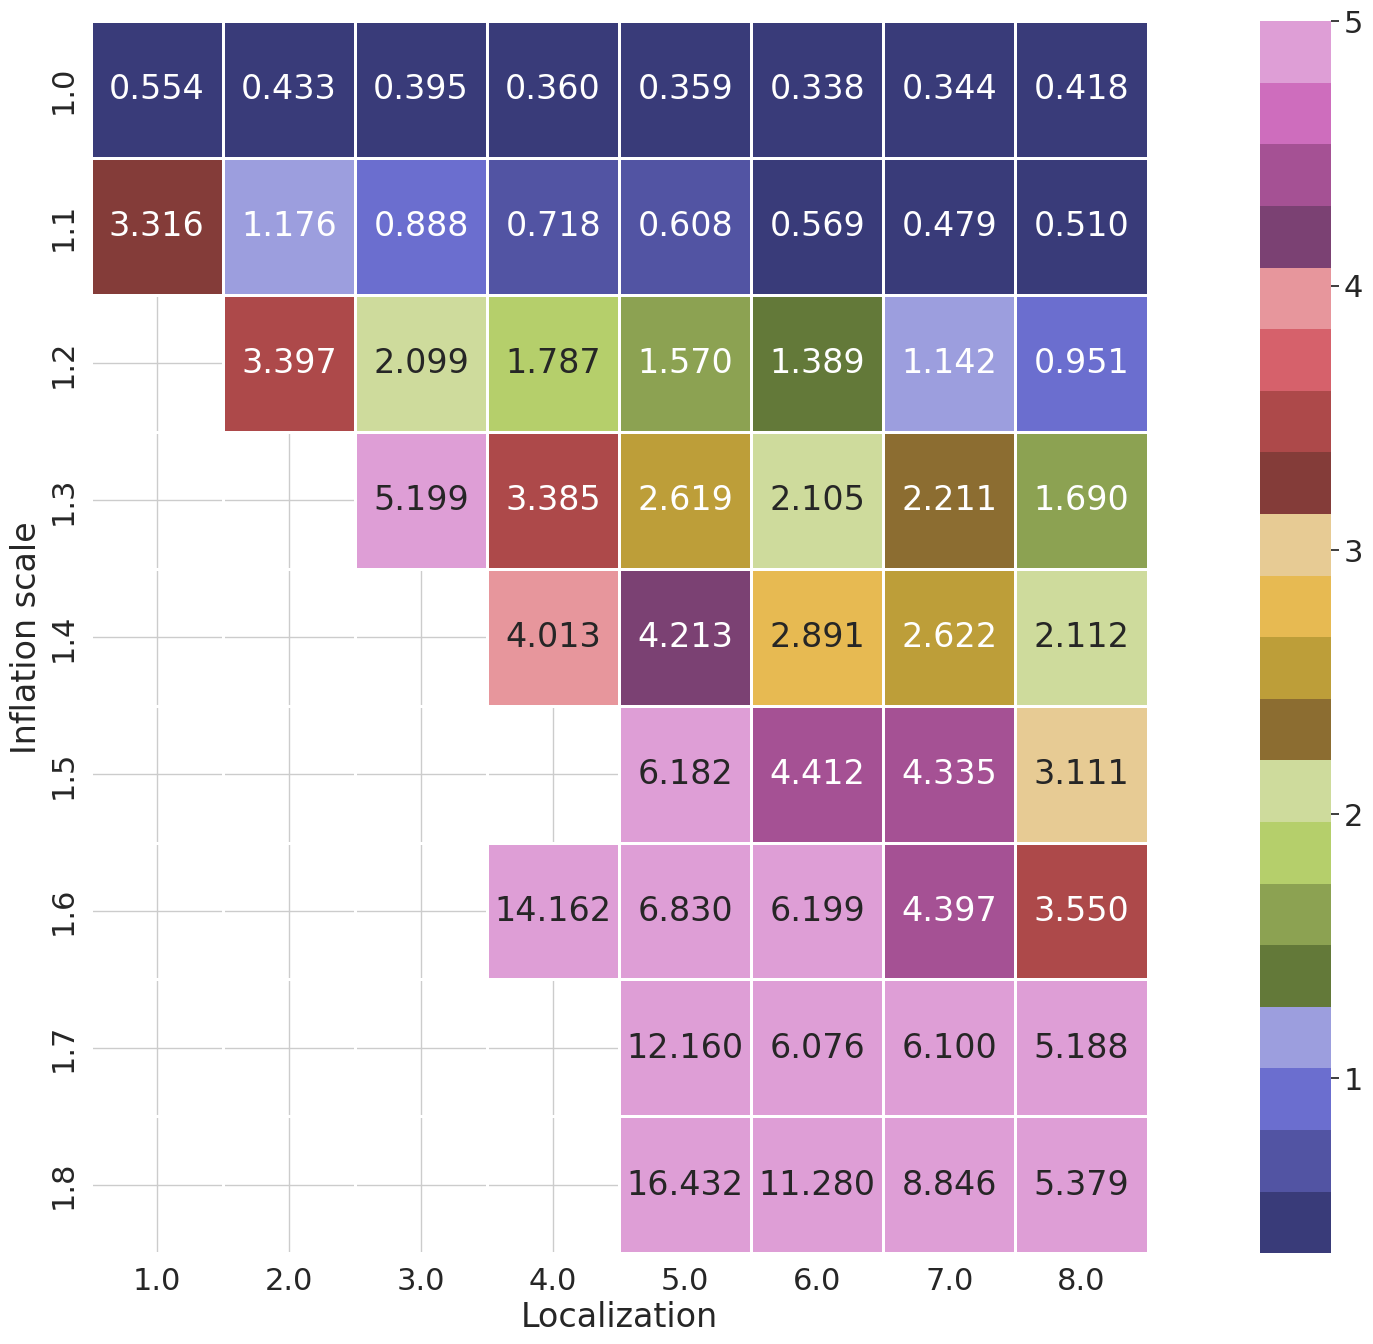

In [183]:
fig, (ax, ax_cbar) = plt.subplots(1, 2, width_ratios=[15, 1], figsize=(16, 16))
# colors = np.vstack([
#     c(np.linspace(0, 1, 4)) for c in [
#         # plt.cm.Greys_r,
#         plt.cm.Blues_r,
#         plt.cm.Greens_r,
#         plt.cm.Oranges_r,
#         plt.cm.Reds_r,
#         plt.cm.Purples_r,
#     ]
# ])
# rmse_max = math.ceil(rmses_pivot.max().max())
# cmap = matplotlib.colors.LinearSegmentedColormap.from_list('my_cmap', colors)
rmse_max = 5
(
    sns.heatmap(
        data=rmses_pivot,
        linewidths=1,
        annot=True,
        fmt='.3f',
        vmax=rmse_max,
        # norm=matplotlib.colors.BoundaryNorm(boundaries=list(itertools.chain(*[
        #     np.linspace(l, r, 4, endpoint=False) for l, r in zip(range(rmse_max), range(1, rmse_max + 1))
        # ])), ncolors=256),
        # cmap=cmap,
        cmap='tab20b',
        ax=ax,
        cbar_ax=ax_cbar,
    )
)
fig.savefig('Tune.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)